# Jet graph construction study

Inspect CPEN jet graphs from TopTagging four-vectors. Compare **directed kNN** (production) with a prototype **star hypergraph**.

```bash
pip install matplotlib  # notebook only
```

In [3]:
import sys
from pathlib import Path

REPO = Path("..").resolve() if (Path("..") / "src" / "cpen").exists() else Path(".").resolve()
sys.path.insert(0, str(REPO / "src"))

DATA_ROOT = "/scratch/gpfs/BHANIN/jdezoort/datasets/toptagging"
NUM_PARTICLES = 100
K = 8
JET_IDX = 0

%matplotlib inline

In [4]:
from cpen.utils.graph_plotting import (
    build_jet_graph,
    compare_constructions,
    load_jet_sample,
    plot_construction_panel,
    plot_fidelity_dashboard,
    summarize_graph,
)

sample = load_jet_sample(data_root=DATA_ROOT, split="train", idx=JET_IDX, num_particles=NUM_PARTICLES)
print(f"label={'top' if sample['y']==1 else 'QCD'}  active={int(sample['mask'].sum())} particles")

[data] Loaded 1211000 jets from train.h5 (100 particles/jet, 4 features)
label=QCD  active=23 particles


In [5]:
graph_knn = build_jet_graph(sample, k=K, construction="knn")
summarize_graph(graph_knn)

{'construction': '8-NN',
 'label': 0,
 'n_particles_active': 23,
 'n_edges': 800,
 'n_edges_valid': 184,
 'edges_per_particle': 34.78260869565217,
 'mean_node_degree': 15.0,
 'max_node_degree': 19.0,
 'mean_hyperedge_size': 0.4312500059604645,
 'max_hyperedge_size': 2.0,
 'mean_spatial_edge_length': 24.94651985168457,
 'max_spatial_edge_length': 460.6139831542969,
 'mutual_directed_pairs': 156,
 'self_loop_edges': 31,
 'padding_edges': 616}

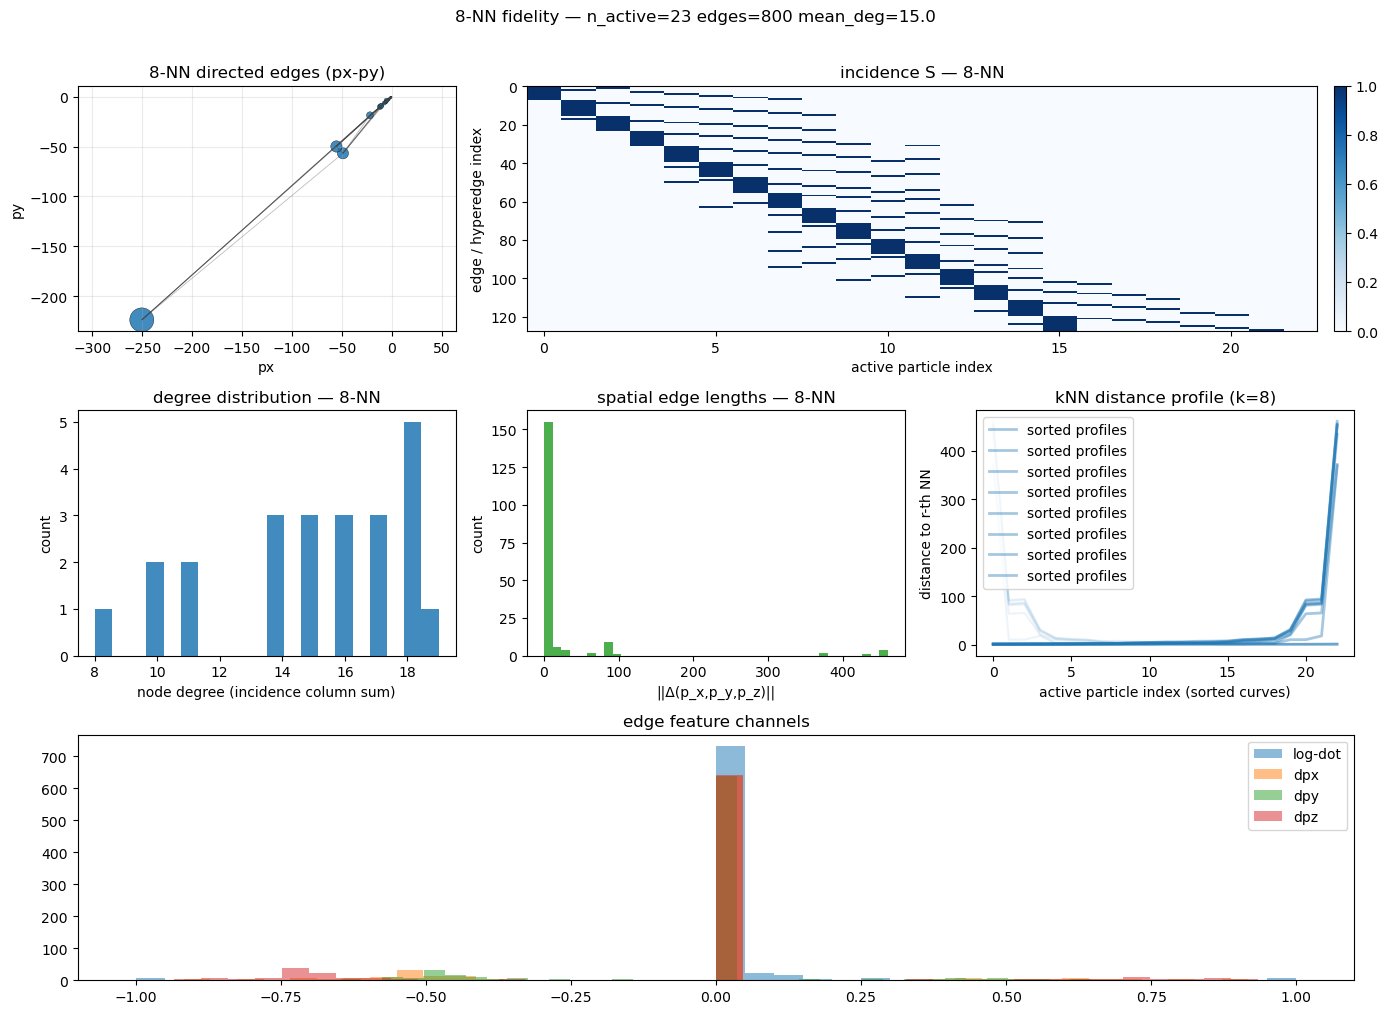

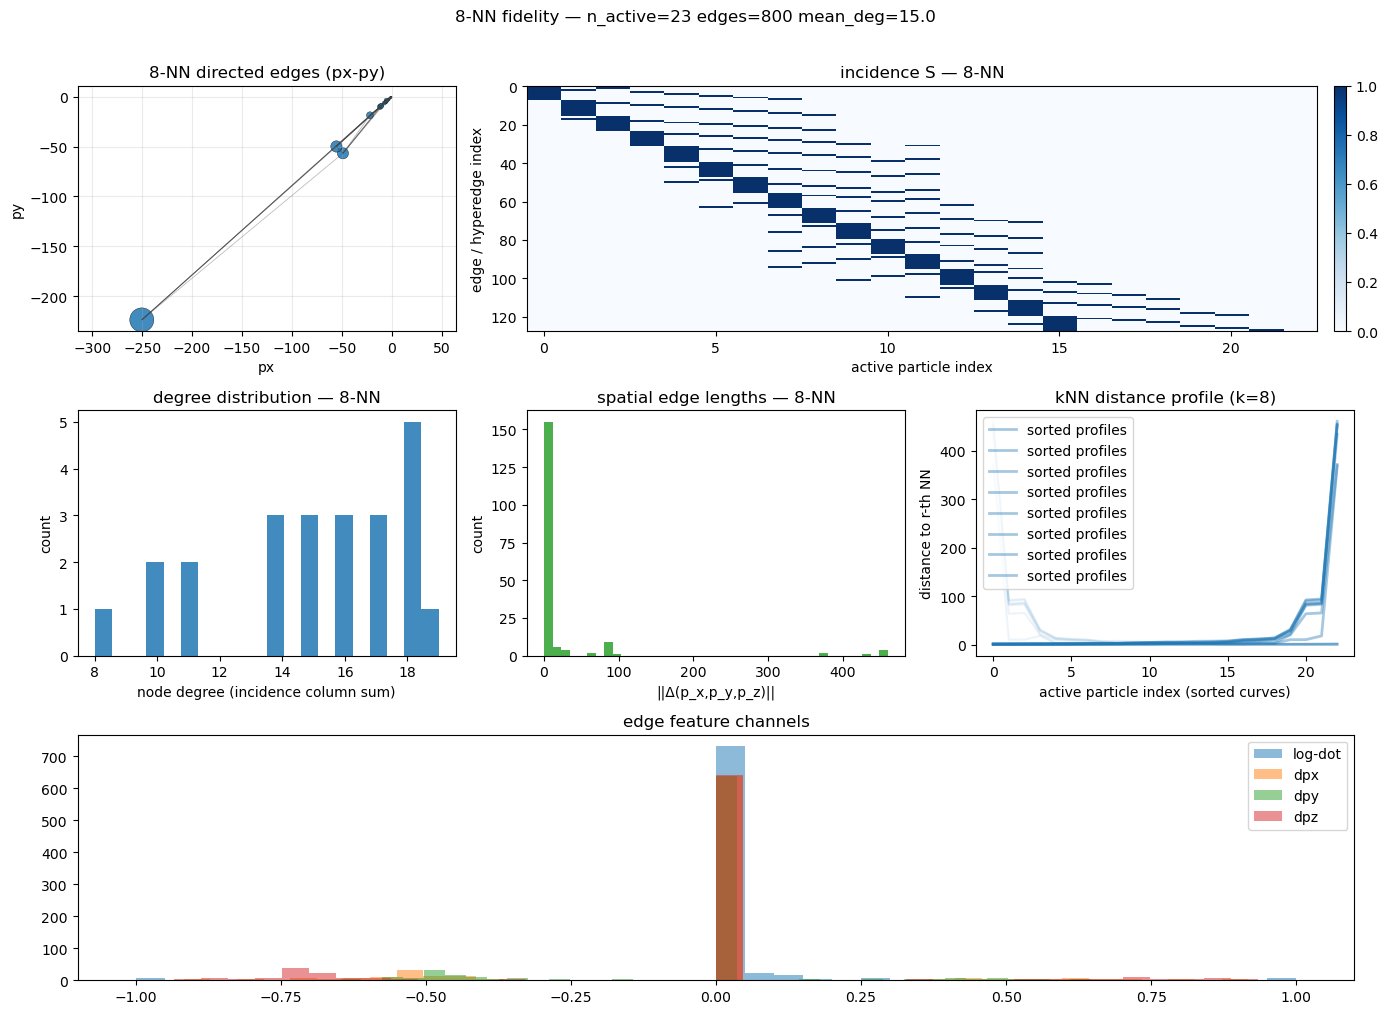

In [6]:
fig, graph, stats = plot_fidelity_dashboard(sample, k=K, construction="knn")
fig

In [7]:
compare_constructions(sample, k=K)

IndexError: Dimension out of range (expected to be in range of [-1, 0], but got 1)

In [ ]:
plot_construction_panel(sample, k=K, plane="px-py")